# 03. Optimización de la cartera

En el notebook anterior calculé la rentabilidad anual de cada activo y la matriz de covarianzas. Aquí uso esos datos para responder a la pregunta de Markowitz: **¿qué pesos dan el mejor equilibrio entre rentabilidad y riesgo?**

Pasos de este notebook:
1. Cargar los resultados del notebook 02.
2. Comprobar las funciones de cartera con un reparto de pesos iguales.
3. Buscar la cartera de **mínima varianza**.
4. Construir la **frontera eficiente**.
5. Encontrar la cartera de **máximo ratio de Sharpe**.

### Carga de datos

Leo la rentabilidad anual, la matriz de covarianzas y la tasa libre de riesgo guardadas en `data/`.

In [21]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Leo lo que guardé en el notebook anterior
cov_anual = pd.read_csv("../data/cov_anual.csv", index_col=0)
rentabilidad_anual = pd.read_csv("../data/rentabilidad_anual.csv", index_col=0).squeeze("columns")
rf_hist = pd.read_csv("../data/rf_hist.csv", index_col=0).squeeze("columns")["rf_hist"]

activos = cov_anual.index
n = len(activos)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Funciones de cartera

- `vol_cartera(w, cov)`: volatilidad de la cartera, $\sigma_p = \sqrt{w^\top \Sigma\, w}$
- `rent_cartera(w, mu)`: rentabilidad de la cartera, $\mu_p = w^\top \mu$

Primero las pruebo con una cartera de **pesos iguales** (1/6 en cada activo).

In [22]:
import sys
sys.path.append("..")   # el notebook está en notebooks/, así que subo a la raíz del proyecto

from src.portfolio import vol_cartera, rent_cartera

cov = cov_anual.values
mu = rentabilidad_anual.values

w_igual = np.repeat(1/n, n)
vol_cartera(w_igual, cov), rent_cartera(w_igual, mu)

(np.float64(0.12204495833920627), np.float64(0.0984949188225674))

**Resultado:** la cartera de pesos iguales tiene una rentabilidad anual del **9,85 %** y una volatilidad del **12,20 %**. Este reparto será el punto de comparación para las carteras optimizadas.

### Cartera de mínima varianza

La cartera de **mínima varianza** es la que tiene el menor riesgo posible, sin importar la rentabilidad. Como no hay una fórmula sencilla con restricciones, se la pido a un optimizador (`scipy.optimize.minimize`).

El problema es:

$$\min_w \; w^\top \Sigma\, w \quad \text{sujeto a} \quad \sum_i w_i = 1, \quad 0 \le w_i \le 1$$

- La primera restricción dice que todo el capital está invertido.
- La segunda prohíbe las posiciones cortas ($w<0$ sería apostar contra el activo).


In [23]:
from src.portfolio import cartera_min_varianza

w_min = cartera_min_varianza(cov)

pesos = pd.DataFrame({"Pesos iguales": w_igual, "Pesos (Mín. varianza)": w_min}, index=activos)
pesos.round(3)

,Pesos iguales,Pesos (Mín. varianza)
AGG,0.167,0.939
EEM,0.167,0.000
EFA,0.167,0.000
GLD,0.167,0.007
SPY,0.167,0.054
VNQ,0.167,0.000


In [24]:
comparacion = pd.DataFrame({
    "Rentabilidad": [rent_cartera(w_igual, mu), rent_cartera(w_min, mu)],
    "Volatilidad":  [vol_cartera(w_igual, cov), vol_cartera(w_min, cov)],
}, index=["Pesos iguales", "Mín. varianza"])

comparacion.round(4)

,Rentabilidad,Volatilidad
Pesos iguales,0.0985,0.1220
Mín. varianza,0.0292,0.0528


La cartera de mínima varianza tiene una volatilidad del **5,28 %**, frente al 12,20 % de la de pesos iguales. Los pesos se concentran en **AGG (93,9 %)**, con algo de **SPY (5,4 %)** y casi nada de **GLD (0,7 %)**. EEM, EFA y VNQ quedan en 0.

El optimizador premia a los activos poco volátiles y poco correlacionados con el resto, como AGG. EEM, EFA y VNQ están muy correlacionados con SPY, así que no aportan diversificación y se descartan. El coste es la rentabilidad: **2,92 %**, frente al 9,85 % de pesos iguales. Además, queda ligeramente por encima de la tasa libre de riesgo (2,25 % (\*)).

### Frontera eficiente

La cartera de mínima varianza minimiza el riesgo sin mirar la rentabilidad. Pero un inversor puede aceptar más riesgo a cambio de más rentabilidad. Por eso, para cada **rentabilidad objetivo** busco los pesos con la menor volatilidad que la consiguen:

$$\min_w \; w^\top \Sigma\, w \quad \text{sujeto a} \quad \sum_i w_i = 1, \quad w^\top \mu = \mu_{objetivo}, \quad 0 \le w_i \le 1$$

Repito el problema para 50 rentabilidades objetivo, desde la de la mínima varianza hasta la del activo más rentable. Los puntos resultantes forman la **frontera eficiente**: ninguna cartera posible ofrece más rentabilidad con el mismo riesgo.

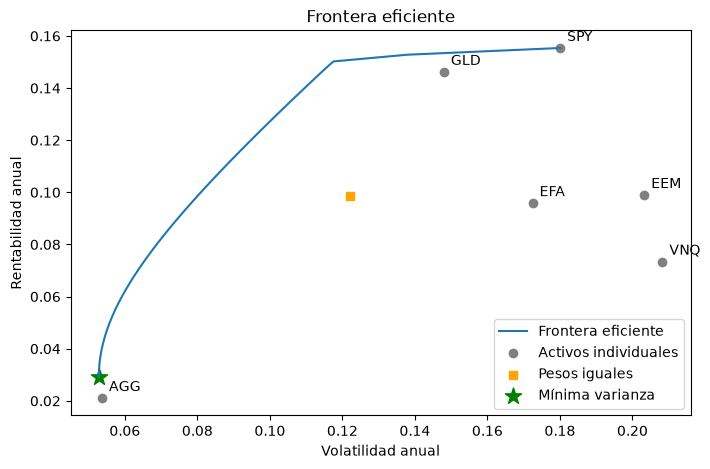

In [25]:
from src.portfolio import frontera_eficiente

rents, vols, pesos_frontera = frontera_eficiente(cov, mu)

vol_activos = np.sqrt(np.diag(cov))     # volatilidad de cada activo por separado

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(vols, rents, label="Frontera eficiente")
ax.scatter(vol_activos, mu, color="gray", label="Activos individuales")
for nombre, x, y in zip(activos, vol_activos, mu):
    ax.annotate(nombre, (x, y), textcoords="offset points", xytext=(5, 5))

ax.scatter(vol_cartera(w_igual, cov), rent_cartera(w_igual, mu),
           marker="s", color="orange", label="Pesos iguales")
ax.scatter(vol_cartera(w_min, cov), rent_cartera(w_min, mu),
           marker="*", s=150, color="green", label="Mínima varianza")

ax.set_xlabel("Volatilidad anual")
ax.set_ylabel("Rentabilidad anual")
ax.set_title("Frontera eficiente")
ax.legend()
plt.show()

In [26]:
tabla_pesos = pd.DataFrame(pesos_frontera, columns=activos)
tabla_pesos.index = rents.round(3)
tabla_pesos.iloc[::7].round(2)      # una fila de cada 7, para no ver las 50

,AGG,EEM,EFA,GLD,SPY,VNQ
0.029,0.94,0.0,0.0,0.01,0.05,0.0
0.047,0.80,0.0,0.0,0.09,0.11,0.0
0.065,0.66,0.0,0.0,0.18,0.16,0.0
0.083,0.52,0.0,0.0,0.27,0.21,0.0
0.101,0.38,0.0,0.0,0.35,0.27,0.0
0.119,0.24,0.0,0.0,0.44,0.32,0.0
0.137,0.10,0.0,0.0,0.53,0.38,0.0
0.155,0.00,0.0,0.0,0.00,1.00,0.0


- La frontera va desde la cartera de mínima varianza (volatilidad 5,28 %, rentabilidad 2,92 %) hasta una cartera 100 % en SPY (volatilidad 18 %, rentabilidad 15,5 %).
- **Solo intervienen AGG, GLD y SPY.** EEM, EFA y VNQ tienen peso 0 en toda la frontera: ofrecen menos rentabilidad que SPY con más riesgo.
- AGG domina en las carteras de poco riesgo; al subir la rentabilidad objetivo su peso baja hasta 0 (el codo de la curva, cerca del 15 % de rentabilidad) y después la cartera mezcla GLD y SPY.
- **La cartera de pesos iguales es ineficiente:** con su misma volatilidad (12,20 %), la frontera permite una rentabilidad cercana al 15 %.
- Todos los activos quedan por debajo de la frontera, salvo SPY, que está en su extremo.
- El tramo inicial de la frontera, con rentabilidades apenas por encima de la tasa libre de riesgo (2,25 %), es poco atractivo: se asume riesgo para ganar casi lo mismo que con las letras del Tesoro.

**Limitaciones:** las rentabilidades y covarianzas son históricas (2016-2025) y se tratan como si fueran las futuras. La optimización amplifica los errores de estimación, y por eso los pesos resultan tan concentrados. Es un ejercicio sobre datos pasados, no una recomendación de inversión.

### Cartera de máximo ratio de Sharpe

La frontera eficiente ofrece muchas carteras, cada una con su equilibrio entre rentabilidad y riesgo. Para escoger una, uso el **ratio de Sharpe**: la rentabilidad extra sobre la tasa libre de riesgo por cada unidad de volatilidad.

$$\text{Sharpe} = \frac{\mu_p - r_f}{\sigma_p}$$

Como `minimize` solo minimiza, se minimiza el Sharpe con signo negativo, con las mismas restricciones que antes (pesos suman 1, sin posiciones cortas). Geométricamente, la cartera resultante es la que toca la frontera con la recta más inclinada que parte de $(0, r_f)$.

Uso $r_f = 2{,}25\,\%$ (la variable `rf_hist`), la misma tasa libre de riesgo del notebook 02, para que todo el proyecto sea coherente.

In [27]:
from src.portfolio import cartera_max_sharpe, ratio_sharpe

w_sharpe = cartera_max_sharpe(cov, mu, rf_hist)

In [28]:
pesos_carteras = pd.DataFrame({
    "Pesos iguales": w_igual,
    "Mín. varianza": w_min,
    "Máx. Sharpe": w_sharpe,
}, index=activos)

pesos_carteras.round(3)

,Pesos iguales,Mín. varianza,Máx. Sharpe
AGG,0.167,0.939,0.000
EEM,0.167,0.000,0.000
EFA,0.167,0.000,0.000
GLD,0.167,0.007,0.583
SPY,0.167,0.054,0.417
VNQ,0.167,0.000,0.000


In [29]:
carteras = {"Pesos iguales": w_igual, "Mín. varianza": w_min, "Máx. Sharpe": w_sharpe}

comparacion = pd.DataFrame({
    "Rentabilidad": [rent_cartera(w, mu) for w in carteras.values()],
    "Volatilidad":  [vol_cartera(w, cov) for w in carteras.values()],
    "Sharpe":       [ratio_sharpe(w, cov, mu, rf_hist) for w in carteras.values()],
}, index=carteras.keys())

comparacion.round(3)

,Rentabilidad,Volatilidad,Sharpe
Pesos iguales,0.098,0.122,0.623
Mín. varianza,0.029,0.053,0.127
Máx. Sharpe,0.150,0.117,1.088


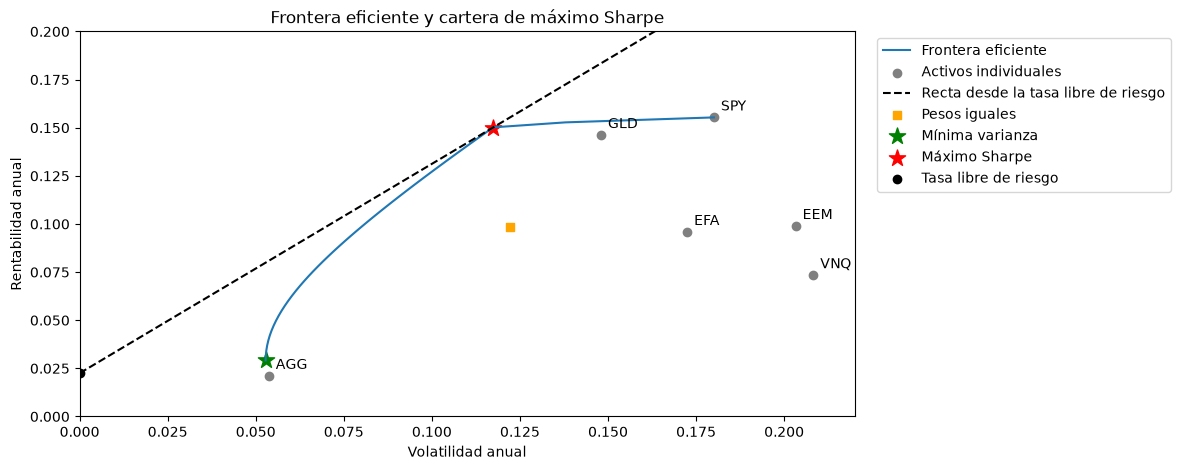

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(vols, rents, label="Frontera eficiente")
ax.scatter(vol_activos, mu, color="gray", label="Activos individuales")
for nombre, x, y in zip(activos, vol_activos, mu):
    ax.annotate(nombre, (x, y), textcoords="offset points", xytext=(5, 5))

vol_s = vol_cartera(w_sharpe, cov)
rent_s = rent_cartera(w_sharpe, mu)

# Recta que parte de la tasa libre de riesgo y pasa por la cartera de máximo Sharpe
x_recta = np.linspace(0, 0.22, 50)
ax.plot(x_recta, rf_hist + (rent_s - rf_hist) / vol_s * x_recta,
        "--", color="black", label="Recta desde la tasa libre de riesgo")

ax.scatter(vol_cartera(w_igual, cov), rent_cartera(w_igual, mu),
           marker="s", color="orange", label="Pesos iguales")
ax.scatter(vol_cartera(w_min, cov), rent_cartera(w_min, mu),
           marker="*", s=150, color="green", label="Mínima varianza")
ax.scatter(vol_s, rent_s, marker="*", s=150, color="red", label="Máximo Sharpe")
ax.scatter(0, rf_hist, color="black", label="Tasa libre de riesgo")

ax.set_xlim(0, 0.22)
ax.set_ylim(0, 0.20)
ax.set_xlabel("Volatilidad anual")
ax.set_ylabel("Rentabilidad anual")
ax.set_title("Frontera eficiente y cartera de máximo Sharpe")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

### Conclusiones

| Cartera | Rentabilidad | Volatilidad | Sharpe |
|---|---|---|---|
| Pesos iguales | 9,8 % | 12,2 % | 0,62 |
| Mínima varianza | 2,9 % | 5,3 % | 0,13 |
| Máximo Sharpe | 15,0 % | 11,7 % | 1,09 |

- **La cartera de máximo Sharpe invierte un 58,3 % en oro (GLD) y un 41,7 % en el S&P 500 (SPY).** Con una volatilidad algo menor que la de pesos iguales (11,7 % frente a 12,2 %), consigue unos 5 puntos más de rentabilidad.
- **Por qué esos dos activos:** son los de mayor Sharpe individual (0,84 y 0,74) y casi no están correlacionados entre sí (0,05), de modo que combinarlos reduce mucho el riesgo.
- **El resto de activos recibe peso 0.** EEM, EFA y VNQ están muy correlacionados con SPY y rinden menos. AGG rinde menos que la tasa libre de riesgo en este periodo.
- **Cada cartera responde a un objetivo distinto:** la de mínima varianza minimiza el riesgo, pero casi no gana nada sobre las letras del Tesoro; la de máximo Sharpe maximiza la rentabilidad por unidad de riesgo.

**Limitaciones:**
- El resultado depende mucho del excelente comportamiento del oro en 2016-2025 (14,6 % anual). Si el oro rinde menos en el futuro, la cartera óptima dejaría de serlo.
- Optimizar y evaluar con los mismos datos favorece el resultado (sobreajuste). El Sharpe de 1,09 es una cota optimista, no una expectativa.
- Las carteras son muy concentradas (solo dos activos), algo típico de Markowitz con estimaciones históricas.